In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import os
import importlib
import functions
import matplotlib.pyplot as plt
from typing import Optional
importlib.reload(functions)

<module 'functions' from '/home/aetoropa/temp-attribution-1to31days/functions.py'>

In [80]:
# Frost client ID (You need this to download METNO observations from FROST)
# You can obtain a personal ID from: https://frost.met.no/authentication.html
frost_client_id = "9a43639e-6f86-4a9e-b664-a2fbddf57b81"

# Data provider (FMI,SMHI,METNO)
obs_source = "METNO"

# Station ID (e.g. 101932 = Sodankylä, 100971 = Kaisaniemi)
station_id = "101932"

# Station2 ID (only for some SMHI stations)
station2_id = None

# Climate variable (tas, tasmax, tasmin)
clim_var = "tasmin"


In [74]:
# ---- Attribution cases ----

# Preindustrial climate year
preind_year = 1900

# Target climate year
target_year = 2025

# Future climate year (Set 'future_year' = None, if you don't want attribution results for future climate)
future_year = 2050

# Compute attribution results for observations
use_obs = True

# Start Month (1-12)
start_month = 7

# Start day (1-31)
start_day = 12

# End month (1-12)
end_month = 7

# End day (1-31)
end_day = 25

doy_index, n_days = functions.get_doy_index_and_ndays(start_month, start_day, end_month, end_day)
print(doy_index, n_days)

200 14


In [ ]:
# Start date (DD-MM-YYYY)
print("31-12-2025")

# End date (DD-MM-YYYY)
print("13-01-2026")

31-12-2025
13-01-2026


In [62]:
# The first and last years of observations used in the calculation of probability distributions
base1_year = 1901
base2_year = 2024

# Probability of warmer temperatures (colder if false)
pwarm = True

# Scenario for future climate: Currently, only ssp245 is available.
ssp = "ssp585"

# Number of bootstrap samples (if n_boots = 0, bootstrapping will NOT be applied)
n_boots = 10

# The daily mean temperature is within -50 ... +40 C
valmin = -50.0
valmax = 40.0
nbins = 1601

# Temperature range array
T_range = np.linspace(valmin, valmax, nbins)

# Quantiles for quantile regression (QR)
quantiles = np.arange(0.01,1.00,0.01)

# Paths to directories for reading data and saving the output figures
input_data_dir = "/home/aetoropa/temp-attribution-1to31days/input_data"
path2figures = "/home/aetoropa/temp-attribution-1to31days/figures/"
path2results_files = "/home/aetoropa/temp-attribution-1to31days/attribution_results"

In [63]:
# A dictionary for attribution cases
attribution_cases = {
    "preind":preind_year,
    "target":target_year,
}

if future_year is not None:
    attribution_cases["future"] = future_year
    
if use_obs is not None:
    attribution_cases["obs"] = "obs"

# Save initialization variables to dictionary, so it's easier to pass them all to functions as arguments
config_vars = {
    "obs_source": obs_source,
    "station_id": station_id,
    "ssp": ssp,
    "clim_var": clim_var,
    "doy_index": doy_index,
    "n_days": n_days,
    "base1_year": base1_year,
    "base2_year": base2_year,
    "quantiles": quantiles
}

In [231]:
importlib.reload(functions)

<module 'functions' from '/home/aetoropa/temp-attribution-1to31days/functions.py'>

In [232]:
def read_irish_data(data:pd.DataFrame)->pd.DataFrame:

    cols = data[0].str.split(",", expand=True)

    df = cols[[0, 2]].copy()
    df.columns = ["date", "temperature"]

    df["date"] = pd.to_datetime(df["date"], format="%d-%b-%Y", errors="coerce")
    df["temperature"] = pd.to_numeric(df["temperature"], errors="coerce")

    df = df.dropna(subset=["date"])
    df = df.set_index("date").sort_index()

    df = df[~((df.index.month == 2) & (df.index.day == 29))]

    ref_year = 2001
    df["month_day"] = df.index.strftime("%m-%d")
    df["ref_date"] = pd.to_datetime(str(ref_year) + "-" + df["month_day"])
    df["day_of_year"] = df["ref_date"].dt.dayofyear

    df["year"] = df.index.year

    pivot_df = df.pivot(index="year", columns="day_of_year", values="temperature")

    return pivot_df

In [71]:
def get_all_time_maximum(obs_df: pd.DataFrame, n_days: int) -> dict:
    """
    Find the all-time maximum n-day mean temperature.

    Parameters
    ----------
    obs_df : pd.DataFrame
        Rows = years, columns = day-of-year.
    n_days : int
        Length of averaging period.

    Returns
    -------
    dict
        Contains:
        - value
        - year
        - doy_index
        - period
    """

    # Convert to Series with MultiIndex (year, day_of_year)
    stacked = obs_df.stack()

    # Find maximum
    max_value = stacked.max()
    year, doy_index = stacked.idxmax()

    # Convert to date string
    period, _ = functions.get_date_strings(
        doy_index=doy_index,
        n_days=n_days
    )

    return {
        "value": max_value,
        "year": int(year),
        "doy_index": int(doy_index),
        "period": period
    }

In [187]:
importlib.reload(functions)

<module 'functions' from '/home/aetoropa/temp-attribution-1to31days/functions.py'>

In [82]:
# Read the observational data (SMHI: remember to provide station2_id if needed)
daily_temp_obs_df, station_meta = functions.read_daily_obs(obs_source, clim_var, station_id, station2_id, frost_client_id=frost_client_id)

# Compute n-day running mean of the observations if needed
if n_days > 1:
    obs_df = functions.compute_running_mean(daily_temp_obs_df, n_days)
else:
    obs_df = daily_temp_obs_df

# Check the validity of observations
functions.check_obs_validity(obs_df, doy_index, n_days, target_year)


26280 observations were downloaded from 10-03-1955 to 06-16-2026.

Observation for the period 12 – 25 July 2025 is valid.
Proceeding with attribution...



In [83]:
get_all_time_maximum(obs_df,n_days)
#print(station_meta)


{'value': 25.72142857142857,
 'year': 2025,
 'doy_index': 199,
 'period': '11 – 24 July'}

In [56]:
importlib.reload(functions)

<module 'functions' from '/home/aetoropa/temp-attribution-1to31days/functions.py'>

In [69]:
anomaly, anomaly_std = functions.get_30yr_anomaly(obs_df,doy_index,target_year)

In [70]:
print(anomaly)
print(anomaly_std)

4.693571428571431
2.326548812075177


In [59]:
# Read observed global mean temp and merge it with the simulated temperature for the model mean (mm) and single model (sm) cases
glob_temp_mm_df = functions.read_sim_temp_model_mean(input_data_dir, clim_var, ssp,window=11)
glob_temp_sm_df = functions.read_sim_temp_single_models(input_data_dir, clim_var, ssp,window=11)

# Read model mean (mm) and single model (sm) regression coefficients
coeffs_mm_ds = functions.read_coeffs_model_mean(input_data_dir, clim_var, ssp, station_meta["latitude"], station_meta["longitude"], n_days)
coeffs_sm_ds = functions.read_coeffs_single_models(input_data_dir, clim_var, ssp, station_meta["latitude"], station_meta["longitude"], n_days)

# Number of models used in the calculation
n_models = len(glob_temp_sm_df.columns)

KeyError: "not all values found in index 'ndays'. Try setting the `method` keyword argument (example: method='nearest')."

In [278]:
# Multi-model mean pseudo-obs and quantiles
pseudo_obs_mm_dict, qr_obs_mm_dict = functions.get_pseudo_obs_and_qr_mm(attribution_cases, config_vars, input_data_dir, obs_df, coeffs_mm_ds, glob_temp_mm_df,n_harmonics=6)

In [291]:
# Single-model pseudo-obs and quantiles
pseudo_obs_sm_dict, qr_sm_dict = functions.get_pseudo_obs_and_qr_sm(attribution_cases, config_vars, input_data_dir, obs_df, coeffs_sm_ds, glob_temp_sm_df, n_boots,n_harmonics=6)

In [242]:
importlib.reload(functions)
print(functions.get_date_strings(doy_index,n_days))

('12 – 25 July', '0712-0725')


1908
200


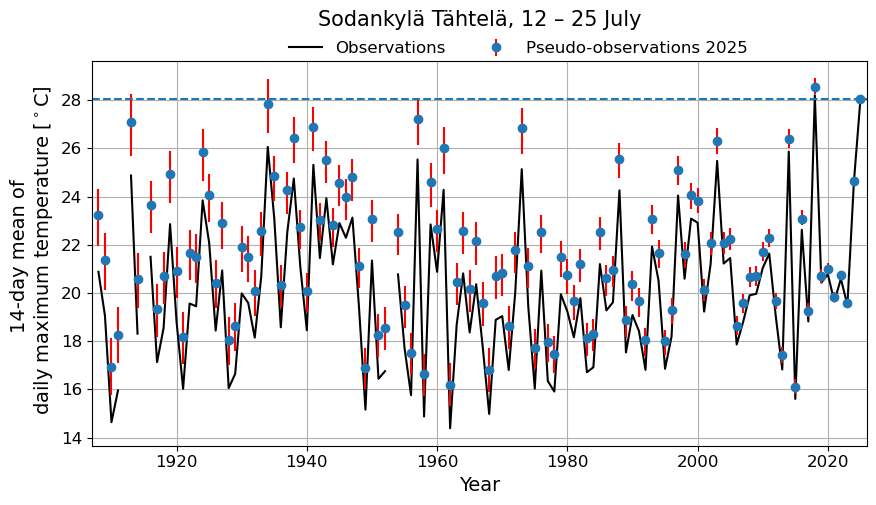

In [280]:
importlib.reload(functions)
functions.plot_time_series(path2figures, obs_source, clim_var, station_meta["name"], target_year, obs_df, pseudo_obs_mm_dict["target"], pseudo_obs_sm_dict["target"], doy_index, n_days)

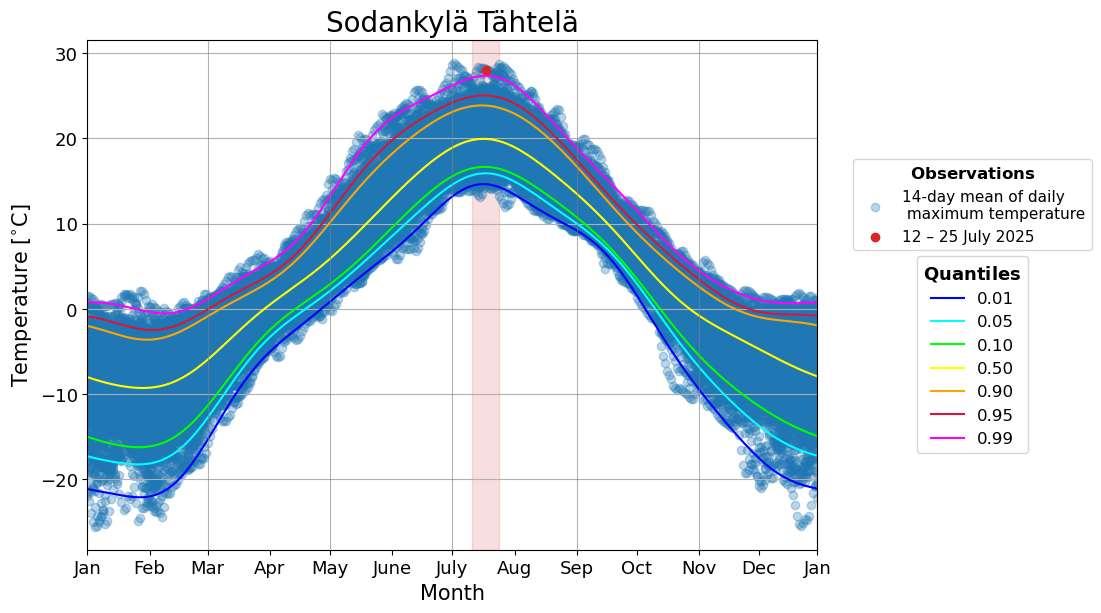

In [281]:
importlib.reload(functions)
functions.plot_observations(path2figures, obs_source, clim_var, station_meta["name"], target_year, obs_df, qr_obs_mm_dict["obs"], doy_index, n_days)

In [282]:
CDF_mm_dict, PDF_mm_dict = functions.get_mm_distributions(qr_obs_mm_dict, quantiles, T_range, doy_index)

In [30]:
#plt.figure(figsize=(10,6))

#plt.scatter(qr_obs_mm_dict["preind"][doy_index].values,quantiles,marker="x",s=30,alpha=0.5,color="#1b9e77")
#plt.scatter(qr_obs_mm_dict["target"][doy_index].values,quantiles,marker="x",s=30,alpha=0.5,color="royalblue")
#plt.scatter(qr_obs_mm_dict["future"][doy_index].values,quantiles,marker="x",s=30,alpha=0.5,color="#e7298a")

#plt.plot(T_range, CDF_mm_dict["preind"],label=1900,color="#1b9e77")
#plt.plot(T_range, CDF_mm_dict["target"],label=2025,color="royalblue")
#plt.plot(T_range, CDF_mm_dict["future"],label=2050,color="#e7298a")

#plt.xlim(10,35)
#plt.xlabel(r"Temperature [$^{\circ}$C]", fontsize=13)
#plt.ylabel("Cumulative probability", fontsize=13)
#plt.grid()
#plt.legend()

In [283]:
print(doy_index)
print(n_days)
print(target_year)

200
14
2025


In [ ]:
from tqdm import tqdm

def apply_bootstrapping(
    doy_index: int,
    T_range: np.ndarray,
    n_boots: int,
    quantiles: np.ndarray,
    qr_obs_mm_dict:dict,
    qr_sm_dict:dict) -> dict:

    # Get the QR-dataframes from the dictionaries
    quantiles_sm_preind = qr_sm_dict["preind"]
    quantiles_sm_target = qr_sm_dict["target"]
    quantiles_sm_future = qr_sm_dict.get("future", None)
    quantiles_obs = qr_obs_mm_dict.get("obs", None)

    # Number of models
    n_models = quantiles_sm_preind.shape[1]

    # Check if obs and future quantiles are used
    use_obs = quantiles_obs is not None
    use_future = quantiles_sm_future is not None

    # Initialize empty arrays
    CDF_sm_preind_array = np.empty((len(T_range), n_models, n_boots+1))
    CDF_sm_target_array = np.empty((len(T_range), n_models, n_boots+1))

    if use_obs:
        CDF_obs_array = np.empty((len(T_range), n_boots+1))
    
    if use_future:
        CDF_sm_future_array = np.empty((len(T_range), n_models, n_boots+1))

    #np.random.seed(42)
    pbar = tqdm(total=n_boots+1, desc="Bootstrapping", unit="bootstrap iteration")

    # Apply bootstrapping to single-model quantiles for 'n_boots' + 1 (deterministic case) times 
    b = 0
    while b < n_boots+1:
        
        if b == 0:

            # Deterministic bootstrap
            random_quantiles = quantiles_sm_preind.index

            bootstrap_sample_preind = quantiles_sm_preind.loc[random_quantiles]
            bootstrap_sample_target = quantiles_sm_target.loc[random_quantiles]
            
            if use_obs:
                bootstrap_sample_obs = quantiles_obs.loc[random_quantiles, doy_index]
            
            if use_future:
                bootstrap_sample_future = quantiles_sm_future.loc[random_quantiles]
            
        else:
            # Random bootstrap quantile sample (0.01,...,0.99) taken by replacement   
            random_quantiles = quantiles_sm_preind.index.to_series().sample(n=99,axis=0,replace=True)

            # Take the same random quantile sample from the pre-industrial and present-day climates
            bootstrap_sample_preind = quantiles_sm_preind.loc[random_quantiles]
            bootstrap_sample_target = quantiles_sm_target.loc[random_quantiles]

            # Take the "same random quantile sample" from observations if they are used
            if use_obs:
                bootstrap_sample_obs = quantiles_obs.loc[random_quantiles, doy_index]
            
            # Take the same random quantile sample from future climate if it is used
            if use_future:
                bootstrap_sample_future = quantiles_sm_future.loc[random_quantiles]
           
        try:
            # Estimate CDFs for observations and pseudo-observations
            CDF_sm_preind = get_CDF_single_models(bootstrap_sample_preind, quantiles, T_range)
            CDF_sm_target = get_CDF_single_models(bootstrap_sample_target, quantiles, T_range)
            
            if use_obs:
                CDF_obs, _ = functions.estimate_CDF_and_PDF_from_quantiles(quantiles, bootstrap_sample_obs.values, T_range)
            
            if use_future:
                CDF_sm_future = get_CDF_single_models(bootstrap_sample_future, quantiles, T_range)
            
        except ValueError as e:
            #print(f"Bootstrap {b+1} failed. Retrying with new random quantiles...")
            #print(e)
            continue
        
        # Check for monotonicity
        if not monotonic_sm(CDF_sm_preind):
            continue

        if not monotonic_sm(CDF_sm_target):
            continue
        
        if use_obs and not monotonic(CDF_obs):
            continue

        if use_future and not monotonic_sm(CDF_sm_future):
            continue

        # Save the monotonic CDFs
        CDF_sm_preind_array[:, :, b] = CDF_sm_preind.T
        CDF_sm_target_array[:, :, b] = CDF_sm_target.T
        
        if use_obs:
            CDF_obs_array[:, b] = CDF_obs
                    
        if use_future:
            CDF_sm_future_array[:, :, b] = CDF_sm_future.T

        b+=1
        pbar.update(1)
    
    pbar.close()

    # Store results in dictionary
    bootstrapping_results_dict = {
        "preind": CDF_sm_preind_array,
        "target": CDF_sm_target_array}
    
    if use_obs:
        bootstrapping_results_dict["obs"] = CDF_obs_array
    
    if use_future:
        bootstrapping_results_dict["future"] = CDF_sm_future_array

    return bootstrapping_results_dict

In [295]:
importlib.reload(functions)
#functions.get_date_strings(doy_index,n_days,target_year)

<module 'functions' from '/home/aetoropa/temp-attribution-1to31days/functions.py'>

In [292]:

if n_boots > 0:
    bstrap_results_dict = functions.apply_bootstrapping(n_boots, doy_index, T_range, quantiles, qr_obs_mm_dict, qr_sm_dict)
else:
    bstrap_results_dict = None

Bootstrapping:  18%|█▊        | 2/11 [00:01<00:05,  1.56bootstrap iteration/s]/home/aetoropa/temp-attribution-1to31days/functions.py:3446: RuntimeWarning: overflow encountered in exp
  return np.exp(-np.exp(-(T - mu) / beta))
Bootstrapping: 100%|██████████| 11/11 [00:07<00:00,  1.54bootstrap iteration/s]


In [298]:
importlib.reload(functions)
# The observed temperature corresponding to the target year and doy_index
target_value = obs_df.loc[target_year][doy_index]

# The corresponding index in the T_range array
#index = int((len(T_range)-1)*(target_value - min(T_range)) / (max(T_range - min(T_range))))
index = functions.get_element_index(T_range,target_value)

# Percentile in today's climate
prob = CDF_mm_dict["target"][index]

# Compute probabilities for exceeding or being below the target temperature between the pre-industrial and target climates
probabilities = functions.calculate_probabilities(pwarm, index, CDF_mm_dict, bstrap_results_dict)

# Find temperatures corresponding to the percentile in the present-day climate
percentile_temps = functions.get_percentile_temp_in_climates(prob, T_range, CDF_mm_dict)

# Calculate confidence intervals for intensity change 
if bstrap_results_dict is not None:
    dI_intervals = functions.calculate_dI_intervals(index, T_range, bstrap_results_dict)
else:
    dI_intervals = None

# Print the results
functions.print_attribution_results(attribution_cases, obs_source, station_meta, clim_var, doy_index, n_days, target_value, probabilities, percentile_temps, dI_intervals)

# Save the results to a csv-file
#functions.save_attribution_results(path2results_files,attribution_cases,obs_source,station_meta,clim_var,doy_index,n_days,target_value,anomaly,anomaly_std, probabilities,percentile_temps,dI_intervals)


Attribution results for FMI station 101932 (Sodankylä Tähtelä):

Location: (67.37 °N, 26.63 °E)
Climate variable: 14-day mean of daily maximum temperature
Time-period: 12 – 25 July

Annual probabilities:
1900: 0.38% (0.04% - 1.09%)
2025: 1.79% (0.34% - 4.81%)
2050: 3.86% (0.66% - 11.78%)

Annual temperatures:
1900: 25.9°C (24.8°C - 27.7°C)
2025: 28.0°C
2050: 29.0°C (28.1°C - 30.2°C)

Probability ratio: 4.6 (1.2 - 22.1)
Change in intensity: 2.1°C (0.3°C - 3.3°C)


In [170]:
print(doy_index)

146


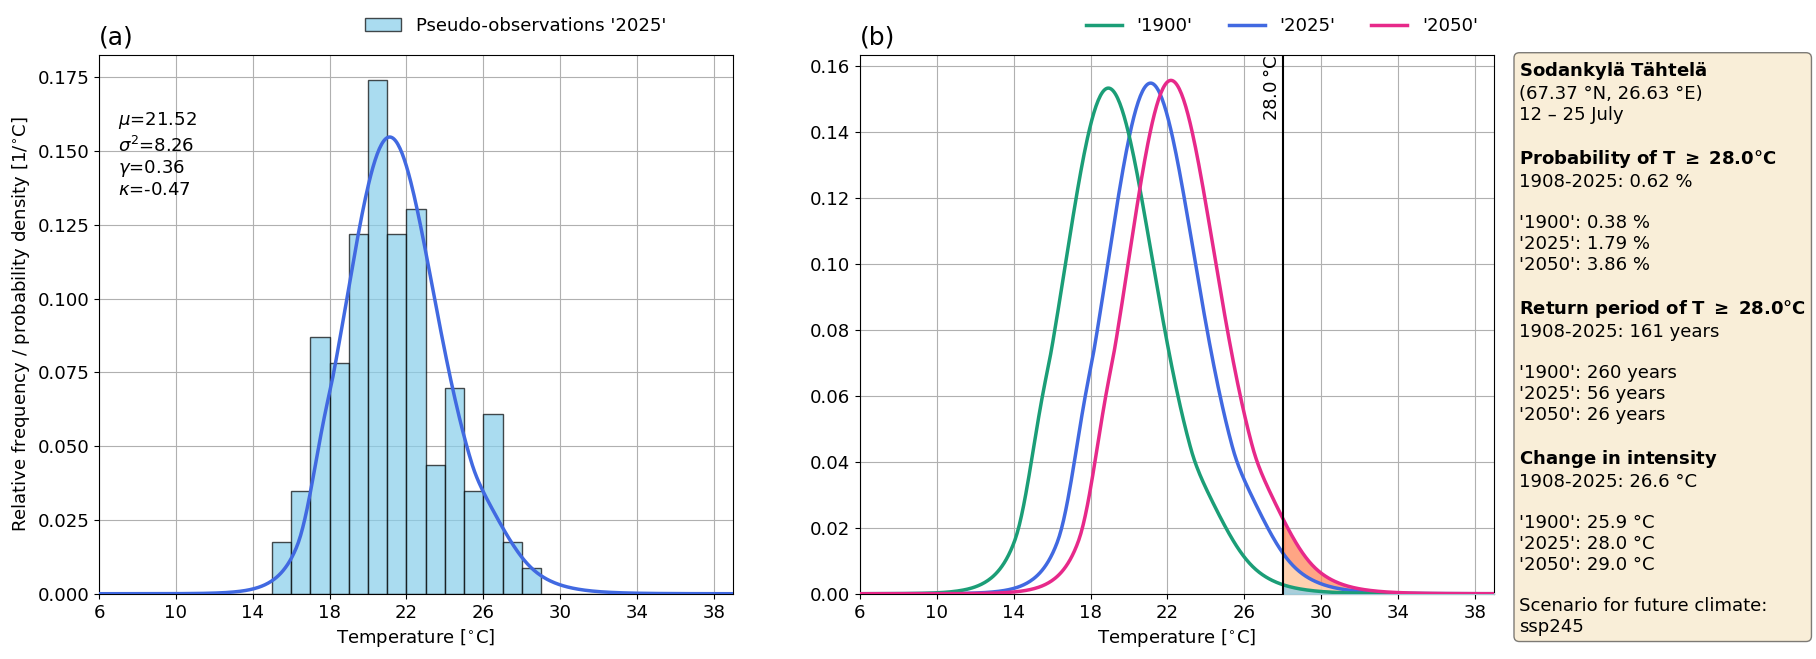

In [287]:
functions.plot_distributions(path2figures, attribution_cases, obs_source, clim_var, station_meta, ssp, T_range, doy_index, n_days, pwarm, target_value, pseudo_obs_mm_dict["target"], PDF_mm_dict, probabilities, percentile_temps, dI_intervals)

5


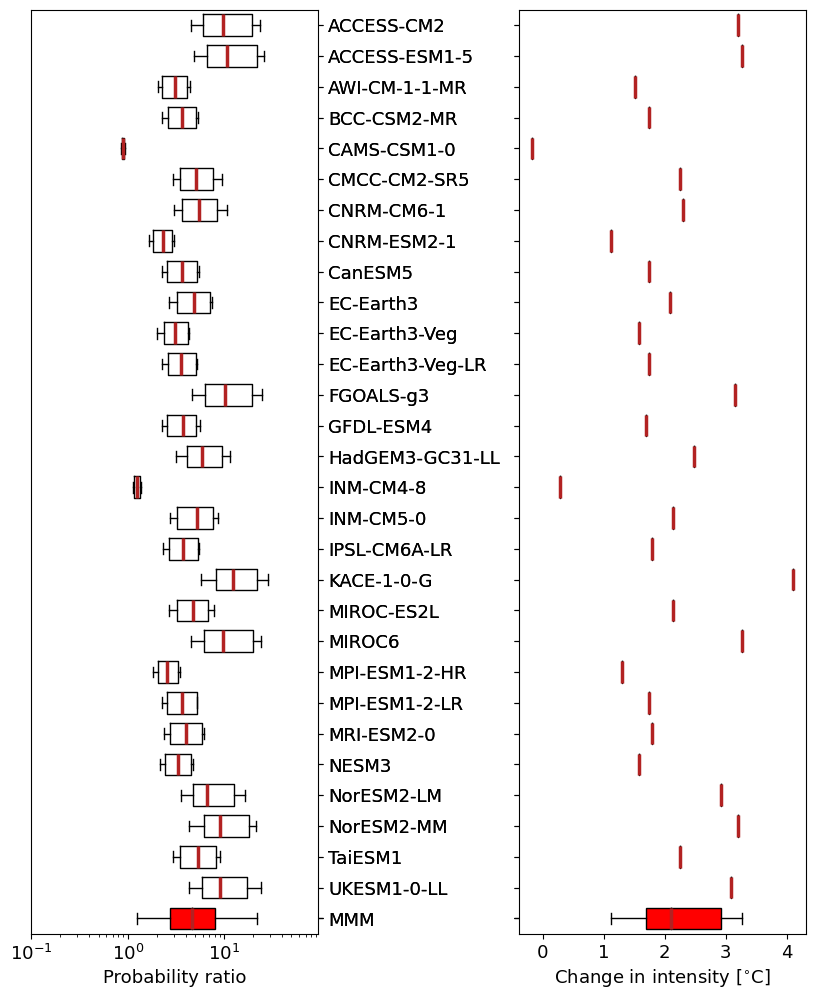

In [300]:
importlib.reload(functions)
if n_boots > 0:
    model_names = qr_sm_dict["preind"].columns.tolist()
    functions.plot_model_statistics(path2figures, obs_source, clim_var, station_meta, doy_index, n_days, model_names, n_boots, index, target_value, pwarm, bstrap_results_dict,\
                                    probabilities, percentile_temps, dI_intervals)

In [ ]:
from typing import Optional

def get_mean_temperature_over_days(daily_mean_temp_obs_df:pd.DataFrame, start_date:str, end_date:str)->pd.DataFrame:

    """
    Calculates the mean temperature for a range of days from the individual daily mean values.
    
    Parameters:
    df : pandas DataFrame
        The DataFrame containing daily mean temperatures.
    start_date : str
        The starting day of the range in MM-DD form.
    end_day : str
        The ending day of the range in MM-DD form.
    
    Returns:
    pandas Series
        A series with the mean temperatures over the specified range for each year.
    """

    # Convert start and end dates to respective days of year
    start_day_of_year = functions.mm_dd_to_doy(start_date)
    end_day_of_year = functions.mm_dd_to_doy(end_date)

    # Return the mean temperature for the day range
    return daily_mean_temp_obs_df.loc[:, start_day_of_year:end_day_of_year].mean(axis=1)

def extract_attr_results_finland(
    target_date:str,
    locations:list,
    path2input_obs:str,
    path2input_model_data:str,
    path2regressed_obs_model_mean:str,
    path2params:str,
    target_year:int,
    T_range:np.ndarray,
    quantiles:np.ndarray,
    pwarm:bool,
    n_days:int,
    start_date: Optional[str] = None,
    end_date: Optional[str] = None)->pd.DataFrame: 
    
    # A list for saving results
    results = []

    # Loop through locations
    for location in locations:
        
        # Read daily obs
        daily_obs = functions.get_weather_station_obs(path2input_obs,location)
        #print(location)
        
        if n_days > 1:
            daily_obs = get_mean_temperature_over_days(daily_obs, start_date, end_date)

        # Read weather station coordinates
        coordinates = functions.read_weather_station_coordinates(path2input_model_data,"weather_station_coordinates.csv",location)

        try:
            # Guess parameters for the logistic function
            logistic_params = functions.read_logistic_function_params(path2params, location, target_date)

        except KeyError:
            logistic_params = np.array([1,1,1,1,1,1])

        # Read multi-model mean quantile regressed observations
        qr_pseudo_obs_preind = functions.load_regressed_quantiles_model_mean(path2regressed_obs_model_mean,location,"preind",n_days)
        qr_pseudo_obs_target = functions.load_regressed_quantiles_model_mean(path2regressed_obs_model_mean,location,"target",n_days)

        # Fit a probability distribution
        CDF_pseudo_obs_preind, _, _, _ = functions.get_CDF_and_PDF_single_day(qr_pseudo_obs_preind[functions.mm_dd_to_doy(target_date)].values,quantiles,T_range,logistic_params)
        CDF_pseudo_obs_target, _, _, _ = functions.get_CDF_and_PDF_single_day(qr_pseudo_obs_target[functions.mm_dd_to_doy(target_date)].values,quantiles,T_range,logistic_params)

        # The observed temperature (i.e. the target value) on the target date
        if n_days > 1:
            target_value = daily_obs.loc[target_year].round(2)
        else:
            target_value = daily_obs.loc[target_year][functions.mm_dd_to_doy(target_date)].round(2)
        
        # The corresponding index in the T_range array
        index = int((len(T_range)-1)*(target_value - min(T_range)) / (max(T_range - min(T_range))))
        
        # Percentile in today's climate
        prob = CDF_pseudo_obs_target[index]

        # Pre-industrial temperature
        t_preind = np.round(np.squeeze(T_range[np.where(CDF_pseudo_obs_preind == functions.find_nearest(CDF_pseudo_obs_preind, prob))[0]]), 1)

        # Intensity change
        dI = target_value - t_preind
        
        # Compute probability ratio
        if pwarm:
            prob_in_preind = 1 - CDF_pseudo_obs_preind[index]
            prob_in_target = 1 - CDF_pseudo_obs_target[index]
            pr_ratio = prob_in_target / prob_in_preind
        else:
            prob_in_preind = CDF_pseudo_obs_preind[index]
            prob_in_target = CDF_pseudo_obs_target[index]
            pr_ratio = prob_in_preind / prob_in_target

        # Save the results to a list
        results.append({
            "location": location,
            "latitude": coordinates[0],
            "longitude": coordinates[1],
            "dI": dI,
            "pr_ratio": pr_ratio
        })

    # Return the results as a DataFrame
    return pd.DataFrame(results).set_index("location")

In [94]:
importlib.reload(functions)

path2observation_plots = "/home/aetoropa/tas_attribution_tool/observation_plots"

def plot_observations_finland(locations:list, path2input_obs:str, path2regressed_obs_model_mean:str, path2observation_plots:str, target_date:str, target_year:int) -> None:

    # Loop through locations
    for location in locations:
        
        # Read daily mean temperature observations
        daily_mean_temp_obs = functions.get_weather_station_obs(path2input_obs, location)

        # Reshaped the temperature observations
        daily_mean_temp_obs_reshaped = functions.reshape_obs(daily_mean_temp_obs)
        #print(daily_mean_temp_obs_reshaped["day_of_year"].isna().sum())
        #print(daily_mean_temp_obs_reshaped["temperature"].isna().sum())

        # Read quantile regressed observations
        quantile_regressed_obs = functions.load_regressed_quantiles_model_mean(path2regressed_obs_model_mean, location, "obs", 1)

        # Plot observations
        functions.plot_observations(path2observation_plots, location, target_year, target_date, daily_mean_temp_obs_reshaped, quantile_regressed_obs)

In [434]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from adjustText import adjust_text

In [437]:
def plot_attribution_map_finland(date: str, attr_results: pd.DataFrame, variable: str) -> None:
    """
    Plots a map of either intensity change or probability ratio for Finland.

    Parameters:
        date (str): Date string to display in the title.
        attr_results (pd.DataFrame): DataFrame containing 'latitude', 'longitude', and the variable to plot.
        variable (str): Either "dI" (intensity change) or "pr_ratio" (probability ratio).
    """
    assert variable in ["dI", "pr_ratio"], "Variable must be 'dI' or 'pr_ratio'"

    lats = attr_results["latitude"].values
    lons = attr_results["longitude"].values
    values = pd.to_numeric(attr_results[variable], errors="coerce").values
    values = values[~np.isnan(values)]

    vmin, vmax = min(values), max(values)
    if vmin == vmax:
        vmin -= 0.01
        vmax += 0.01
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # Use different colormaps and labels based on variable
    if variable == "dI":
        cmap = cm.YlOrBr
        label = "Intensity Change [°C]"
    else:  # pr_ratio
        cmap = cm.Reds
        label = "Probability Ratio"

    # Create map
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})
    ax.set_extent([19, 32, 59.5, 71], crs=ccrs.PlateCarree())  # Finland bounds

    # Map features
    ax.add_feature(cfeature.LAND, facecolor="white")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6)
    ax.add_feature(cfeature.LAKES, edgecolor="black", facecolor="none")

    # Plot labels with color-coded boxes
    texts = []
    for lon, lat, val in zip(lons, lats, attr_results[variable].values):
        try:
            val = float(val)
            text = ax.text(lon, lat, f"{val:.1f}", fontsize=11, ha="center", va="center",
                           transform=ccrs.PlateCarree(),
                           bbox=dict(facecolor=cmap(norm(val)), alpha=0.85,
                                     edgecolor='black', boxstyle="round,pad=0.2"))
            texts.append(text)
        except (ValueError, TypeError):
            continue  # Skip non-numeric values

    # Avoid text overlap
    adjust_text(texts, ax=ax, expand_text=(1.1, 1.1),
                arrowprops=dict(arrowstyle="-", color="black", lw=0.5))

    # Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation="vertical", shrink=0.7)
    cbar.set_label(label, fontsize=12)
    
    # Date string
    date_str = functions.convert_date_to_string(date)
    date_str_label = f"{date_str} {target_year}"


    # Title
    plt.title(f"{date_str_label}", fontsize=14)
    plt.show()


In [2256]:
def extract_monthly_means(df: pd.DataFrame, column: str) -> pd.Series:
    """
    Extracts monthly means from a DataFrame based on the day-of-year index.

    Parameters:
    df (pd.DataFrame): DataFrame containing daily values with day-of-year as the index.
    column (str): Name of the column to compute monthly means for.

    Returns:
    pd.Series: Monthly mean values.
    """
    df = df.copy()
    df["day_of_year"] = df.index.astype(int)

    # Define month ranges (non-leap year)
    month_bins = [1, 32, 61, 92, 122, 153, 183, 214, 245, 275, 306, 336, 366]
    month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    # Assign months
    df["month"] = pd.cut(df["day_of_year"], bins=month_bins, labels=month_labels, right=False)

    # Compute monthly means with observed=True to avoid FutureWarning
    monthly_means = df.groupby("month", observed=True)[column].mean()

    return monthly_means

def compute_monthly_means(attribution_results:pd.DataFrame, column:str):
    """
    Computes the monthly mean of a specified column in a DataFrame where the date column is in "MM-DD" format.
    
    Parameters:
    df (pd.DataFrame): Input DataFrame containing the date and value columns.
    date_col (str): Name of the column containing dates in "MM-DD" format.
    value_col (str): Name of the column for which monthly means should be computed.
    
    Returns:
    pd.Series: Monthly mean values indexed by month (1-12).
    """
    # Convert date column to datetime format with a placeholder year
    attribution_results["date"] = pd.to_datetime("2000-" + attribution_results["date"], format="%Y-%m-%d")
    
    # Compute monthly means
    monthly_means = attribution_results.groupby(attribution_results["date"].dt.month)[column].mean()
    
    # Rename index for clarity
    monthly_means.index.name = "Month"
    monthly_means = monthly_means.rename_axis(None)  # Remove axis label if preferred
    
    return monthly_means

In [2094]:
def plot_intensity_changes(attribution_results:pd.DataFrame) -> None:

    plt.figure(figsize=(10,6))
    plt.plot(np.arange(1,366,1),attribution_results["dI"],label="1900-2024")
    
    month_start_days = [1, 32, 61, 92, 122, 153, 183, 214, 245, 275, 306, 336, 365]
    month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan']
    plt.xticks(ticks=month_start_days, labels=month_labels)
    plt.xlim(0, 366)
    plt.grid()
    plt.legend()
    plt.ylabel(r"Intensity Change [$^{\circ}$C]")


In [1907]:
def plot_attribution_results(attr_results: pd.DataFrame) -> None:
    num_plots = sum(1 for col in attr_results.columns if col.startswith(("prob", "pr_ratio", "t_", "dI")))
    fig, axes = plt.subplots(nrows=num_plots, ncols=1, figsize=(10, 12), sharex=True)

    if num_plots == 1:
        axes = [axes]  # Ensure axes is always iterable

    days = np.arange(1, 366, 1)

    month_start_days = [1, 32, 61, 92, 122, 153, 183, 214, 245, 275, 306, 336, 365]
    month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan']

    # Plot each parameter in a separate subplot
    plot_idx = 0  # Track subplot index
    for col in attr_results.columns:
        if col.startswith(("prob", "pr_ratio", "t_", "dI")):
            axes[plot_idx].plot(days, attr_results[col], label=col)
            
            if col.startswith("prob"):
                axes[plot_idx].set_ylabel("Probability")
            elif col.startswith("pr_ratio"):
                axes[plot_idx].set_ylabel("Probability ratio")
            elif col.startswith("t_"):
                axes[plot_idx].set_ylabel(r"Temperature [$^{\circ}C$]")
            elif col.startswith("dI"):
                axes[plot_idx].set_ylabel(r"Intensity change [$^{\circ}C$]")

            axes[plot_idx].legend()
            axes[plot_idx].grid(True)
            axes[plot_idx].set_xticks(month_start_days)
            axes[plot_idx].set_xticklabels(month_labels)
            axes[plot_idx].set_xlim(1, 365)
            
            plot_idx += 1  # Move to the next subplot

    # Rotate x-axis labels only on the last subplot
    axes[-1].tick_params(axis="x", rotation=45)

    plt.xlabel("Time")
    plt.suptitle("Attribution diagnostics (Kaisaniemi)")
    plt.tight_layout()
    plt.show()
